# UNKNOWN-FIRST: Malware Triage with Novelty Detection
**Team Garnet_Chronicles | Code Cortex 3.0 | ML part (Rajbir)**

Our idea in one line: a normal malware classifier always says "malware" or "benign", even when it has never seen anything like the file. We add a third answer, **NEEDS_ANALYSIS**, for files that are unclear or look very different from our training data.

Plan:
1. Load and explore the data
2. Clean it
3. Train an XGBoost classifier (malware vs benign)
4. Train an Isolation Forest (how unusual is a file?)
5. Combine both into 3 verdicts: MALWARE / BENIGN / NEEDS_ANALYSIS
6. Pick thresholds on validation data, test once on test data
7. Explain predictions with SHAP
8. Save everything for the API

Note: the dataset has static PE features only (header info, sections, imports...). So this is NOT a zero-day detector. It just knows when a file looks unfamiliar.

In [1]:
!pip install -q xgboost shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42

## 1. Load the data
Upload `malware.csv` to your Google Drive first (MyDrive), then mount the drive.

In [5]:
import os
from google.colab import drive

LOCAL_DATA_PATH = '/content/malware.csv'
LOCAL_SAVE_DIR = '/tmp/unknown_first_model'

if os.path.exists(LOCAL_DATA_PATH):
    print(f"Using local data file: {LOCAL_DATA_PATH}")
    DATA_PATH = LOCAL_DATA_PATH
    SAVE_DIR = LOCAL_SAVE_DIR
else:
    print("Local data file not found, attempting to mount Google Drive...")
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/malware.csv'
    SAVE_DIR = '/content/drive/MyDrive/unknown_first_model'

os.makedirs(SAVE_DIR, exist_ok=True)

Using local data file: /content/malware.csv


In [6]:
# this dataset is usually separated by "|" instead of ","
# if reading with "|" gives only 1 column, the file must be a normal comma CSV
df = pd.read_csv(DATA_PATH, sep='|')
if df.shape[1] == 1:
    df = pd.read_csv(DATA_PATH)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Rows: 138047
Columns: 57


,Name,md5,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,...,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
0,memtest.exe,631ea355665f28d4707448e442fbf5b8,332,224,258,9,0,361984,115712,0,...,4,3.262823,2.568844,3.537939,8797.000000,216,18032,0,16,1
1,ose.exe,9d10f99a6712e28f8acd5641e3a7ea6b,332,224,3330,9,0,130560,19968,0,...,2,4.250461,3.420744,5.080177,837.000000,518,1156,72,18,1
2,setup.exe,4d92f518527353c0db88a70fddcfd390,332,224,3330,9,0,517120,621568,0,...,11,4.426324,2.846449,5.271813,31102.272727,104,270376,72,18,1
3,DW20.EXE,a41e524f8d45f0074fd07805ff0c9b12,332,224,258,9,0,585728,369152,0,...,10,4.364291,2.669314,6.400720,1457.000000,90,4264,72,18,1
4,dwtrig20.exe,c87e561258f2f8650cef999bf643a731,332,224,258,9,0,294912,247296,0,...,2,4.306100,3.421598,5.190603,1074.500000,849,1300,72,18,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138047 entries, 0 to 138046
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Name                         138047 non-null  object 
 1   md5                          138047 non-null  object 
 2   Machine                      138047 non-null  int64  
 3   SizeOfOptionalHeader         138047 non-null  int64  
 4   Characteristics              138047 non-null  int64  
 5   MajorLinkerVersion           138047 non-null  int64  
 6   MinorLinkerVersion           138047 non-null  int64  
 7   SizeOfCode                   138047 non-null  int64  
 8   SizeOfInitializedData        138047 non-null  int64  
 9   SizeOfUninitializedData      138047 non-null  int64  
 10  AddressOfEntryPoint          138047 non-null  int64  
 11  BaseOfCode                   138047 non-null  int64  
 12  BaseOfData                   138047 non-null  int64  
 13 

In [8]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.describe().T

Missing values: 0
Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
Machine,138047.0,4.259069e+03,1.088035e+04,332.0,3.320000e+02,3.320000e+02,3.320000e+02,3.440400e+04
SizeOfOptionalHeader,138047.0,2.258456e+02,5.121399e+00,224.0,2.240000e+02,2.240000e+02,2.240000e+02,3.520000e+02
Characteristics,138047.0,4.444146e+03,8.186783e+03,2.0,2.580000e+02,2.580000e+02,8.226000e+03,4.955100e+04
MajorLinkerVersion,138047.0,8.619774e+00,4.088757e+00,0.0,8.000000e+00,9.000000e+00,1.000000e+01,2.550000e+02
MinorLinkerVersion,138047.0,3.819286e+00,1.186267e+01,0.0,0.000000e+00,0.000000e+00,0.000000e+00,2.550000e+02
SizeOfCode,138047.0,2.425956e+05,5.754485e+06,0.0,3.020800e+04,1.136640e+05,1.203200e+05,1.818587e+09
SizeOfInitializedData,138047.0,4.504867e+05,2.101599e+07,0.0,2.457600e+04,2.631680e+05,3.850240e+05,4.294966e+09
SizeOfUninitializedData,138047.0,1.009525e+05,1.635288e+07,0.0,0.000000e+00,0.000000e+00,0.000000e+00,4.294941e+09
AddressOfEntryPoint,138047.0,1.719561e+05,3.430553e+06,0.0,1.272100e+04,5.288300e+04,6.157800e+04,1.074484e+09
BaseOfCode,138047.0,5.779845e+04,5.527658e+06,0.0,4.096000e+03,4.096000e+03,4.096000e+03,2.028711e+09


## 2. Target column
In this dataset `legitimate = 1` means benign and `0` means malware.
We flip it, because we want **1 = malware** (malware is what we are trying to catch).

is_malware
1    96724
0    41323
Name: count, dtype: int64
Malware %: 70.07
Benign %: 29.93


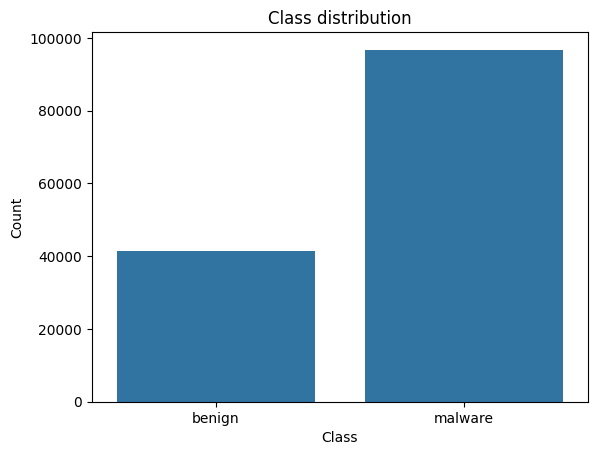

In [9]:
if 'legitimate' not in df.columns:
    raise ValueError("Column 'legitimate' not found. Columns are: " + str(list(df.columns)))

df['is_malware'] = 1 - df['legitimate']

print(df['is_malware'].value_counts())
print("Malware %:", round(df['is_malware'].mean() * 100, 2))
print("Benign %:", round((1 - df['is_malware'].mean()) * 100, 2))

sns.countplot(x=df['is_malware'].map({0: 'benign', 1: 'malware'}))
plt.title('Class distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## 3. Cleaning
- `Name` and `md5` just identify a file (like a roll number). They don't describe the file, so we drop them.
- We remove exact duplicate rows so the same file can't end up in both train and test (that would give a fake high score).
- Missing numbers are filled with the column median.
- No scaling needed: XGBoost and Isolation Forest are tree models, they don't care about scale.

In [10]:
drop_cols = [c for c in ['Name', 'md5'] if c in df.columns]
data = df.drop(columns=drop_cols + ['legitimate'])

before = len(data)
data = data.drop_duplicates()
print("Removed duplicates:", before - len(data))

X = data.drop(columns=['is_malware'])
y = data['is_malware']

# keep only number columns (all PE features in this dataset are numbers)
X = X.select_dtypes(include='number')
X = X.replace([np.inf, -np.inf], np.nan)
FEATURES = list(X.columns)
print("Number of features:", len(FEATURES))

Removed duplicates: 33458
Number of features: 54


## 4. Train / validation / test split
- **Train (64%)**: models learn from this
- **Validation (16%)**: we choose our thresholds using this
- **Test (20%)**: touched only once at the end, to get honest results

In [11]:
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=RANDOM_STATE)

# medians come from TRAIN only, then we use them to fill val and test too
medians = X_train.median()
X_train = X_train.fillna(medians)
X_val = X_val.fillna(medians)
X_test = X_test.fillna(medians)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train: (66936, 54)  Val: (16735, 54)  Test: (20918, 54)


## 5. XGBoost classifier
XGBoost builds many small decision trees, each one fixing the mistakes of the previous ones.
We don't use class weights because malware is already the bigger class here.

In [12]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [13]:
def show_metrics(y_true, prob, name):
    pred = (prob >= 0.5).astype(int)
    print(f"--- {name} ---")
    print("Accuracy :", round(accuracy_score(y_true, pred), 4))
    print("Precision:", round(precision_score(y_true, pred), 4), " (when we say malware, how often are we right)")
    print("Recall   :", round(recall_score(y_true, pred), 4), " (how many real malware did we catch)")
    print("F1       :", round(f1_score(y_true, pred), 4))
    print("ROC-AUC  :", round(roc_auc_score(y_true, prob), 4))

val_prob = model.predict_proba(X_val)[:, 1]
show_metrics(y_val, val_prob, "Validation")

--- Validation ---
Accuracy : 0.9941
Precision: 0.9964  (when we say malware, how often are we right)
Recall   : 0.9939  (how many real malware did we catch)
F1       : 0.9952
ROC-AUC  : 0.9996


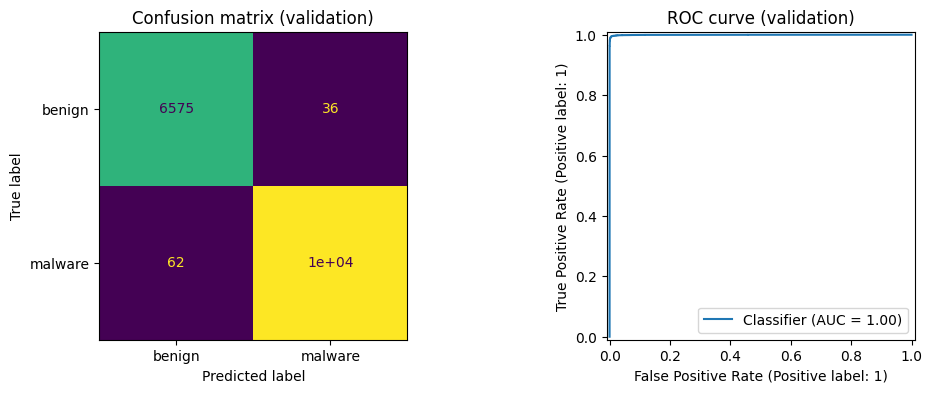

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix(y_val, (val_prob >= 0.5).astype(int)),
                       display_labels=['benign', 'malware']).plot(ax=ax[0], colorbar=False)
ax[0].set_title('Confusion matrix (validation)')
RocCurveDisplay.from_predictions(y_val, val_prob, ax=ax[1])
ax[1].set_title('ROC curve (validation)')
plt.show()

## 6. Novelty detector (Isolation Forest)
Isolation Forest randomly cuts the data. Normal files sit in a crowd and need many cuts to be separated. Weird files get separated in just a few cuts.

We train it on training data only. Then we turn its score into a simple **novelty score from 0 to 1**:
> novelty = what fraction of training files look more normal than this file

So 0.95 means "this file is weirder than 95% of our training files".

Validation files with novelty >= 0.95: 4.88 %  (around 5% is expected)


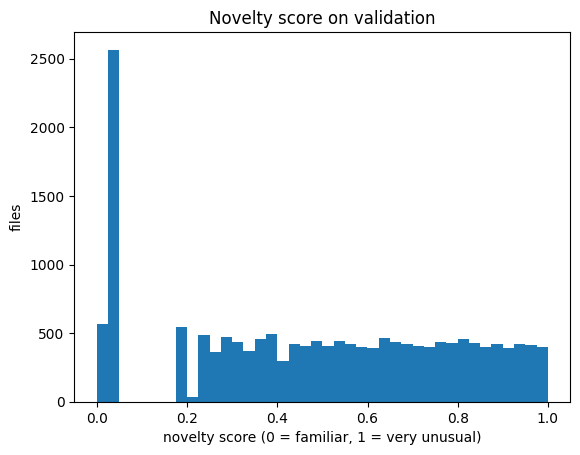

In [15]:
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X_train)

# score_samples gives higher = more normal, so we flip the sign (higher = more weird)
train_weirdness = np.sort(-iso.score_samples(X_train))

def novelty_score(X_part):
    weirdness = -iso.score_samples(X_part)
    # position of each file inside the sorted training scores -> a percentile between 0 and 1
    return np.searchsorted(train_weirdness, weirdness) / len(train_weirdness)

val_novelty = novelty_score(X_val)
print("Validation files with novelty >= 0.95:", round((val_novelty >= 0.95).mean() * 100, 2), "%  (around 5% is expected)")

plt.hist(val_novelty, bins=40)
plt.title('Novelty score on validation')
plt.xlabel('novelty score (0 = familiar, 1 = very unusual)')
plt.ylabel('files')
plt.show()

## 7. Triage rule (the 3 verdicts)
```
probability >= malware_threshold AND novelty < novelty_threshold  -> MALWARE
probability <= benign_threshold  AND novelty < novelty_threshold  -> BENIGN
everything else                                                  -> NEEDS_ANALYSIS
```
Confidence is a simple rule we made (not a real statistical confidence):
- LOW = needs analysis
- HIGH = probability very strong (>= 0.97 or <= 0.03) and file looks normal (novelty < 0.8)
- MEDIUM = everything else

In [16]:
def triage(prob, novelty, malware_t, benign_t, novelty_t):
    if prob >= malware_t and novelty < novelty_t:
        verdict = 'MALWARE'
    elif prob <= benign_t and novelty < novelty_t:
        verdict = 'BENIGN'
    else:
        verdict = 'NEEDS_ANALYSIS'

    if verdict == 'NEEDS_ANALYSIS':
        confidence = 'LOW'
    elif (prob >= 0.97 or prob <= 0.03) and novelty < 0.8:
        confidence = 'HIGH'
    else:
        confidence = 'MEDIUM'
    return verdict, confidence


def evaluate(y_true, probs, novelties, malware_t, benign_t, novelty_t):
    verdicts = [triage(p, n, malware_t, benign_t, novelty_t)[0] for p, n in zip(probs, novelties)]
    res = pd.DataFrame({'actual': np.array(y_true), 'verdict': verdicts})
    decided = res[res['verdict'] != 'NEEDS_ANALYSIS']
    wrong = ((decided['verdict'] == 'MALWARE') & (decided['actual'] == 0)).sum() + \
            ((decided['verdict'] == 'BENIGN') & (decided['actual'] == 1)).sum()
    return {
        'malware_t': malware_t, 'benign_t': benign_t, 'novelty_t': novelty_t,
        'coverage': len(decided) / len(res),                 # share decided automatically
        'abstention': 1 - len(decided) / len(res),           # share sent to analysts
        'error_rate': wrong / len(decided) if len(decided) else 0,  # mistakes among decided files
        'wrong': wrong,
    }, res

## 8. Choosing thresholds (validation only)
Starting values were 0.85 / 0.15 / 0.95. We try a few values around them.

Our rule: analysts can check **at most 10%** of files. Inside that limit we pick the setting with the **fewest mistakes**. If two are tied, we pick the one that decides more files automatically.

In [18]:
rows = []
for m in [0.80, 0.85, 0.90, 0.95]:
    for b in [0.05, 0.10, 0.15, 0.20]:
        for nv in [0.90, 0.95, 0.97, 0.99]:
            rows.append(evaluate(y_val, val_prob, val_novelty, m, b, nv)[0])

grid = pd.DataFrame(rows)
ok = grid[grid['abstention'] <= 0.10].sort_values(['error_rate', 'coverage'], ascending=[True, False])
ok.head(10)

,malware_t,benign_t,novelty_t,coverage,abstention,error_rate,wrong
51,0.95,0.05,0.99,0.971258,0.028742,0.001538,25
50,0.95,0.05,0.97,0.952794,0.047206,0.001568,25
49,0.95,0.05,0.95,0.933313,0.066687,0.001601,25
34,0.90,0.05,0.97,0.955722,0.044278,0.001813,29
35,0.90,0.05,0.99,0.974485,0.025515,0.001840,30
33,0.90,0.05,0.95,0.936122,0.063878,0.001851,29
18,0.85,0.05,0.97,0.957275,0.042725,0.001998,32
19,0.85,0.05,0.99,0.976098,0.023902,0.002020,33
17,0.85,0.05,0.95,0.937616,0.062384,0.002039,32
55,0.95,0.10,0.99,0.974544,0.025456,0.002146,35


In [19]:
if len(ok) > 0:
    best = ok.iloc[0]
else:
    # nothing fits in the 10% limit -> take the setting that sends the fewest files to analysts
    print("No setting kept abstention under 10%, using the one with the lowest abstention instead")
    best = grid.sort_values(['abstention', 'error_rate']).iloc[0]

MALWARE_T, BENIGN_T, NOVELTY_T = float(best['malware_t']), float(best['benign_t']), float(best['novelty_t'])
print("Chosen thresholds -> malware:", MALWARE_T, " benign:", BENIGN_T, " novelty:", NOVELTY_T)

Chosen thresholds -> malware: 0.95  benign: 0.05  novelty: 0.99


## 9. Final test (only once, thresholds are now fixed)

In [20]:
test_prob = model.predict_proba(X_test)[:, 1]
test_novelty = novelty_score(X_test)

show_metrics(y_test, test_prob, "Test - classifier alone")

summary, test_res = evaluate(y_test, test_prob, test_novelty, MALWARE_T, BENIGN_T, NOVELTY_T)
print("\n--- Test - full triage system ---")
print(test_res['verdict'].value_counts())
print("Coverage (decided automatically):", round(summary['coverage'] * 100, 2), "%")
print("Abstention (sent to analysts)  :", round(summary['abstention'] * 100, 2), "%")
print("Error rate on decided files     :", round(summary['error_rate'] * 100, 3), "%")

mal = test_res[test_res['verdict'] == 'MALWARE']
print("MALWARE verdict precision:", round((mal['actual'] == 1).mean(), 4))
print("MALWARE verdict recall   :", round(len(mal[mal['actual'] == 1]) / (test_res['actual'] == 1).sum(), 4))

--- Test - classifier alone ---
Accuracy : 0.9922
Precision: 0.9952  (when we say malware, how often are we right)
Recall   : 0.9918  (how many real malware did we catch)
F1       : 0.9935
ROC-AUC  : 0.9995

--- Test - full triage system ---
verdict
MALWARE           12350
BENIGN             7890
NEEDS_ANALYSIS      678
Name: count, dtype: int64
Coverage (decided automatically): 96.76 %
Abstention (sent to analysts)  : 3.24 %
Error rate on decided files     : 0.247 %
MALWARE verdict precision: 0.9989
MALWARE verdict recall   : 0.9749


In [21]:
pd.crosstab(test_res['actual'].map({0: 'benign', 1: 'malware'}), test_res['verdict'])

verdict,BENIGN,MALWARE,NEEDS_ANALYSIS
actual,,,
benign,7854,14,396
malware,36,12336,282


## 10. Does the novelty detector react to strange files?
We don't have real "new malware family" labels, so we do a simple **synthetic test** (not real malware!):
take 500 test files, push some features to unusual values, and check if the novelty score goes up.

In [22]:
sample = X_test.sample(500, random_state=RANDOM_STATE)
changed_cols = [c for c in ['ImportsNb', 'ImportsNbDLL', 'ResourcesNb', 'SectionsNb'] if c in FEATURES]
print("Changing:", changed_cols)

for k in [0, 1, 3, 5]:
    fake = sample.copy()
    for c in changed_cols:
        fake[c] = fake[c] + k * X_train[c].std()   # push the value up by k standard deviations
    flagged = (novelty_score(fake) >= NOVELTY_T).mean() * 100
    print(f"shift = {k} std  ->  {flagged:.1f}% flagged as novel")

Changing: ['ImportsNb', 'ImportsNbDLL', 'ResourcesNb', 'SectionsNb']
shift = 0 std  ->  0.6% flagged as novel
shift = 1 std  ->  0.6% flagged as novel
shift = 3 std  ->  0.6% flagged as novel
shift = 5 std  ->  2.0% flagged as novel


## 11. Explaining predictions with SHAP
SHAP is like a bill/receipt: it shows how much each feature pushed the prediction.
Positive = towards malware, negative = towards benign.

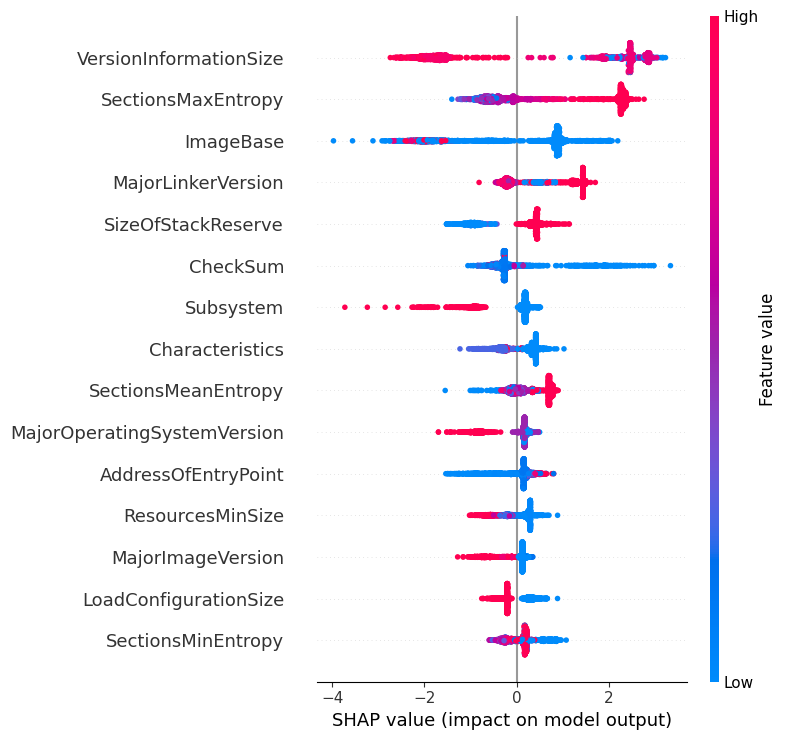

In [23]:
explainer = shap.TreeExplainer(model)
shap_sample = X_test.sample(2000, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample, max_display=15)

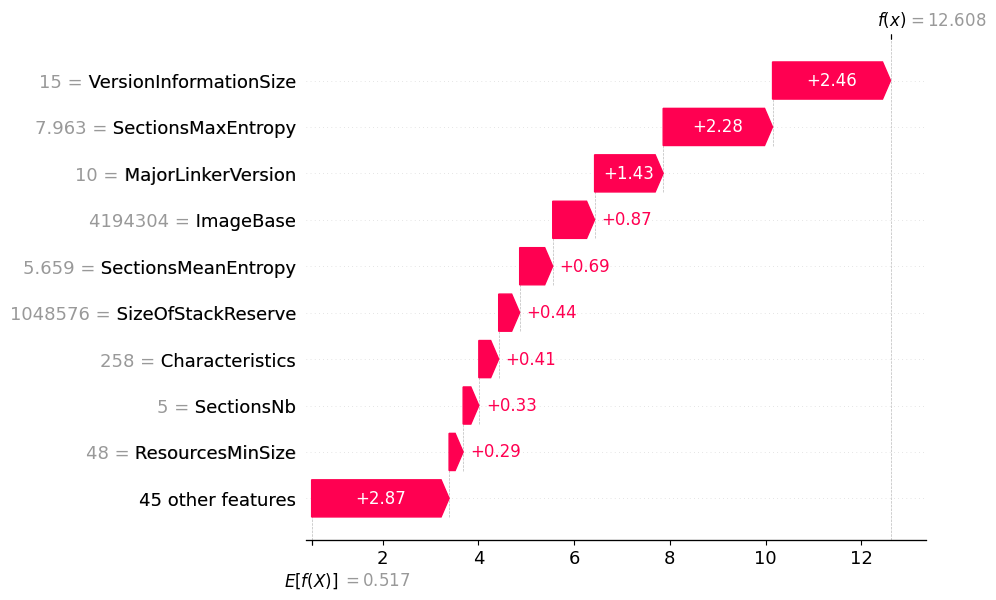

In [24]:
# explain one file the model called malware
idx = test_res.index[test_res['verdict'] == 'MALWARE'][0]
one_file = X_test.iloc[[idx]]
shap.plots.waterfall(explainer(one_file)[0], max_display=10)

## 12. Save the model for the API
Kaustubh's FastAPI calls `predict_components(features)` and gets back probability, novelty and top SHAP features. The verdict itself is made on his side.

In [25]:
joblib.dump(model, f'{SAVE_DIR}/xgb_model.joblib')
joblib.dump(iso, f'{SAVE_DIR}/iforest_model.joblib')
np.save(f'{SAVE_DIR}/train_weirdness.npy', train_weirdness)

config = {
    'features': FEATURES,
    'medians': medians.to_dict(),
    'thresholds': {'malware': MALWARE_T, 'benign': BENIGN_T, 'novelty': NOVELTY_T},
    'model_version': 'xgb-v1',
    'novelty_model_version': 'iforest-v1',
}
with open(f'{SAVE_DIR}/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(os.listdir(SAVE_DIR))

['xgb_model.joblib', 'config.json', 'iforest_model.joblib', 'train_weirdness.npy']


In [26]:
def predict_components(features):
    missing = [c for c in FEATURES if c not in features]
    if missing:
        raise ValueError(f"Missing features: {missing}")

    row = pd.DataFrame([features])[FEATURES].astype(float).fillna(medians)
    prob = float(model.predict_proba(row)[0, 1])
    nov = float(novelty_score(row)[0])

    sv = explainer.shap_values(row)[0]
    top = np.argsort(-np.abs(sv))[:5]
    top_features = [{
        'feature': FEATURES[i],
        'raw_value': float(row.iloc[0, i]),
        'shap_value': float(sv[i]),
        'direction': 'towards_malware' if sv[i] > 0 else 'towards_benign',
    } for i in top]

    return {'malware_probability': prob, 'novelty_score': nov, 'top_shap_features': top_features,
            'model_version': 'xgb-v1', 'novelty_model_version': 'iforest-v1'}

# quick check on one test file
example = X_test.iloc[0].to_dict()
out = predict_components(example)
print(out)
print("Verdict:", triage(out['malware_probability'], out['novelty_score'], MALWARE_T, BENIGN_T, NOVELTY_T))

{'malware_probability': 0.9999966621398926, 'novelty_score': 0.0353920162543325, 'top_shap_features': [{'feature': 'VersionInformationSize', 'raw_value': 15.0, 'shap_value': 2.464348793029785, 'direction': 'towards_malware'}, {'feature': 'SectionsMaxEntropy', 'raw_value': 7.96309810922, 'shap_value': 2.2844221591949463, 'direction': 'towards_malware'}, {'feature': 'MajorLinkerVersion', 'raw_value': 10.0, 'shap_value': 1.432502269744873, 'direction': 'towards_malware'}, {'feature': 'ImageBase', 'raw_value': 4194304.0, 'shap_value': 0.8747445344924927, 'direction': 'towards_malware'}, {'feature': 'SectionsMeanEntropy', 'raw_value': 5.65935611278, 'shap_value': 0.6901960372924805, 'direction': 'towards_malware'}], 'model_version': 'xgb-v1', 'novelty_model_version': 'iforest-v1'}
Verdict: ('MALWARE', 'HIGH')


## 13. Summary
**What the classifier learned:** patterns in PE header, section, import and resource features that separate malware from benign files in this dataset.

**What the novelty detector learned:** what "normal-looking" files in our training data look like. It doesn't use labels at all.

**Why a third verdict:** if a file is unclear, or looks nothing like our training data, it's safer to send it to an analyst than to force a guess.

**What we can claim:** the system combines a classifier with novelty detection and sends unclear or unfamiliar files to NEEDS_ANALYSIS. Thresholds were chosen on validation data and the results above are from an untouched test set.

**What we can't claim:** it does not detect zero-day, AI-generated, polymorphic or fileless malware. The stress test in section 10 used synthetic changes, not real malware.